Empty DataFrame
Columns: [Country, GDP, Region]
Index: []
0


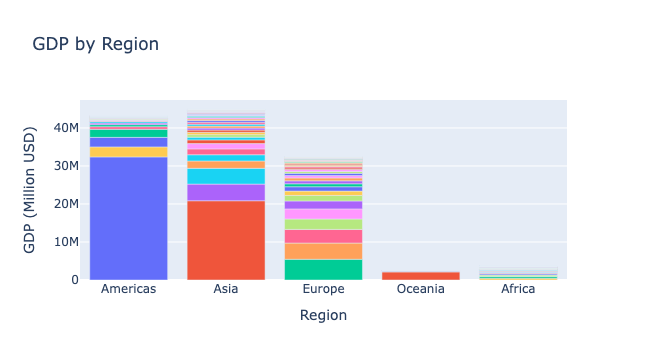

In [2]:
#PROBLEM 1
import requests as rq
import bs4
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
from io import StringIO

url_1 = 'https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)'
url_region = 'https://en.wikipedia.org/w/index.php?title=List_of_countries_by_GDP_(nominal)&oldid=1187446467'
#need to make a user agent per wikipedia policy
headers = {'User-Agent': 'DS4BIOHomework/1.0 (chaturvedi.arnav.9@gmail.com)'}
page_1 = rq.get(url_1, headers = headers)
page_region = rq.get(url_region, headers = headers)

bs4page_1 = bs4.BeautifulSoup(page_1.text, 'html.parser')
bs4page_region = bs4.BeautifulSoup(page_region.text, 'html.parser')
tables_1 = bs4page_1.find('table',{'class':"wikitable"})
tables_region = bs4page_region.find('table', {'id': 'mwmQ'})
GDPbyC = pd.read_html(StringIO(str(tables_1)))[0]
CRs = pd.read_html(StringIO(str(tables_region)))[0]

# clean table
# 1. remove "world" line and clean up any misc text in brackets
# 2. isolate column with IMF data
# 3. locate and isolate missing data 
# 4. fill in data from Worldbank if not available use UN since it is less recent
# 5. add in region info from CRs

#1 and 2
GDPbyC = GDPbyC[GDPbyC['Country/Territory'] != 'World'].reset_index(drop=True)
GDPbyC = GDPbyC.replace(r'\[.*?\]', '', regex=True)
data = GDPbyC[['Country/Territory', 'IMF (2026)[1]']]
data = data.rename(columns = {'Country/Territory': 'Country', 'IMF (2026)[1]': 'GDP'})

#3 and 4
#need to convert all strings to numbers and make sure no years are attached to numbers
def to_num(s):
    first = s.astype(str).str.extract(r'([\d,]+(?:\.\d+)?)')[0]
    return pd.to_numeric(first.astype(str).str.replace(',', ''), errors='coerce')

data['GDP'] = to_num(data['GDP'])
wb = to_num(GDPbyC['World Bank (2025)[6]'])
un = to_num(GDPbyC['United Nations (2024)[7]'])
data['GDP'] = data['GDP'].fillna(wb).fillna(un)

#5
regions = CRs.iloc[:, :2].replace(r'\[.*?\]', '', regex=True)   # country and region columns
regions.columns = ['Country', 'Region']
data = data.merge(regions, on='Country', how='left')

#need at assign missing regions by hand for unavailable data (info from other wikipedia entries on each country)
missing = {
    'Channel Islands': 'Europe',
    'Isle of Man': 'Europe',
    'Faroe Islands': 'Europe',
    'Guam': 'Oceania',
    'American Samoa': 'Oceania',
    'Northern Mariana Islands': 'Oceania',
    'U.S. Virgin Islands': 'Americas',
    'Saint Martin': 'Americas',
}

data['Region'] = data['Region'].fillna(data['Country'].map(missing))

#checks on data prior to plot
print(data[data['Region'].isna()])
print(data['GDP'].isna().sum())

# #make plot
fig = px.bar(data, x = "Region", y = "GDP", color = "Country", 
             hover_name='Country', 
             hover_data = {'Region': False, 'Country': False},
             labels = {'GDP': 'GDP (Million USD)'},
             title = 'GDP by Region')
fig.update_layout(showlegend=False) #legend has too many entries
fig.write_html('stacked_bar.html')
fig.show()


icv 1382418
level1 1382418
level2 1382418
level3 1382418
level4 1382418
roi 1382418


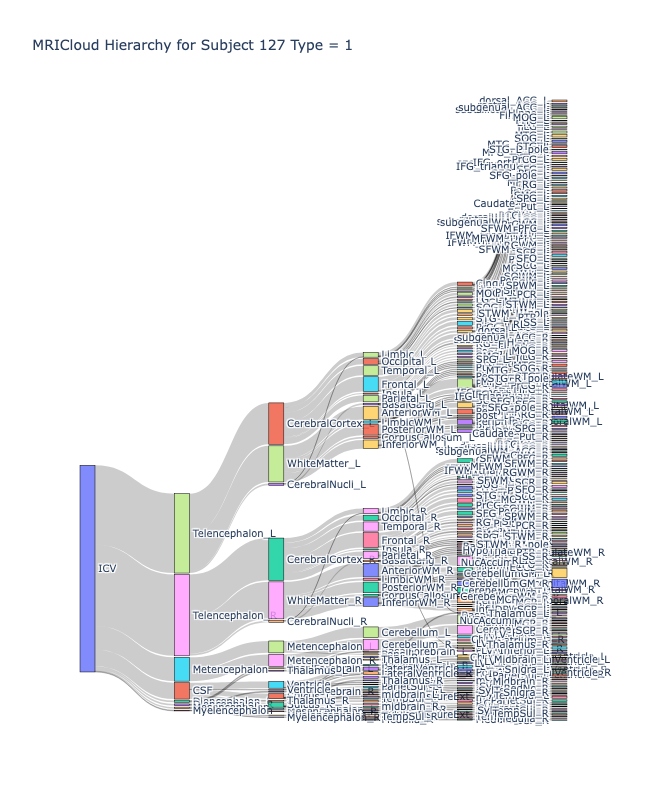

In [3]:
#PROBLEM 2 
# all ##sections directly from lecture
## load in the hierarchy information
url = "https://raw.githubusercontent.com/bcaffo/MRIcloudT1volumetrics/master/inst/extdata/multilevel_lookup_table.txt"
multilevel_lookup = pd.read_csv(url, sep = "\t").drop(['Level5'], axis = 1)
multilevel_lookup = multilevel_lookup.rename(columns = {
    "modify"   : "roi",
    "modify.1" : "level4",
    "modify.2" : "level3",
    "modify.3" : "level2",
    "modify.4" : "level1"})
multilevel_lookup = multilevel_lookup[['roi', 'level4', 'level3', 'level2', 'level1']]
multilevel_lookup.head()

## load in the subject data
subjectData = pd.read_csv("https://raw.githubusercontent.com/smart-stats/ds4bio_book/main/book/assetts/kirby21AllLevels.csv")
id = 127
subjectData = subjectData.loc[(subjectData.type == 1) & 
    (subjectData.level == 5) & 
    (subjectData.id == id)]
subjectData = subjectData[['roi', 'volume']]

## Merge the subject data with the multilevel data
subjectData = pd.merge(subjectData, multilevel_lookup, on = "roi")
subjectData = subjectData.assign(icv = "ICV")
subjectData = subjectData.assign(comp = subjectData.volume / np.sum(subjectData.volume))
subjectData.head()

#make the sankey plot
#make links
levels = ["icv", "level1", "level2", "level3", "level4", "roi"]
links=[]
for i in range(len(levels)-1):
    temp = (subjectData.groupby([levels[i], levels[i+1]])["volume"].sum().reset_index())
    #need unique names for nodes
    temp["source"] = levels[i] + "::" + temp[levels[i]].astype(str)
    temp["target"] = levels[i + 1] + "::" + temp[levels[i + 1]].astype(str)
    temp=temp[["source","target", "volume"]]
    temp.columns = ["source","target","value"]
    links.append(temp)
    
links = pd.concat(links,ignore_index=True)

#make the nodes
nodes=pd.unique(pd.concat([links["source"], links["target"]], ignore_index=True))
#create indicies for nodes for sankey
node_index = {node: i for i, node in enumerate(nodes)}
#clean up label for display
labels = [node.split("::",1)[1]
               for node in nodes]
source = links["source"].map(node_index)
target = links["target"].map(node_index)

#check that total volume is consistent at every level
for level in levels:
    total = subjectData.groupby(level)["volume"].sum().sum()
    print(level, total)

#make plot
fig = go.Figure(data=[go.Sankey(
            arrangement="snap",node=dict(
                pad=15,
                thickness=15,
                line=dict(color="black",width=0.5),
                label=labels),
            link=dict(source=source,target=target,value=links["value"]))])
fig.update_layout(title_text="MRICloud Hierarchy for Subject 127 Type = 1",height = 800, font_size = 10)
fig.show()

#make webpage
fig.write_html("sankey.html")

[Sankey Plot from DS4BIO HW 5](https://chaturvediarnav-jhu.github.io/hw5SankeyPlot/sankey.html)